# **T1A** Viscosidade da água

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import RealData, Model, ODR

In [ ]:
g = 981
rho = 1

In [ ]:
def lin(B,x):
    return B[0]*x+B[1]
linmod=Model(lin)

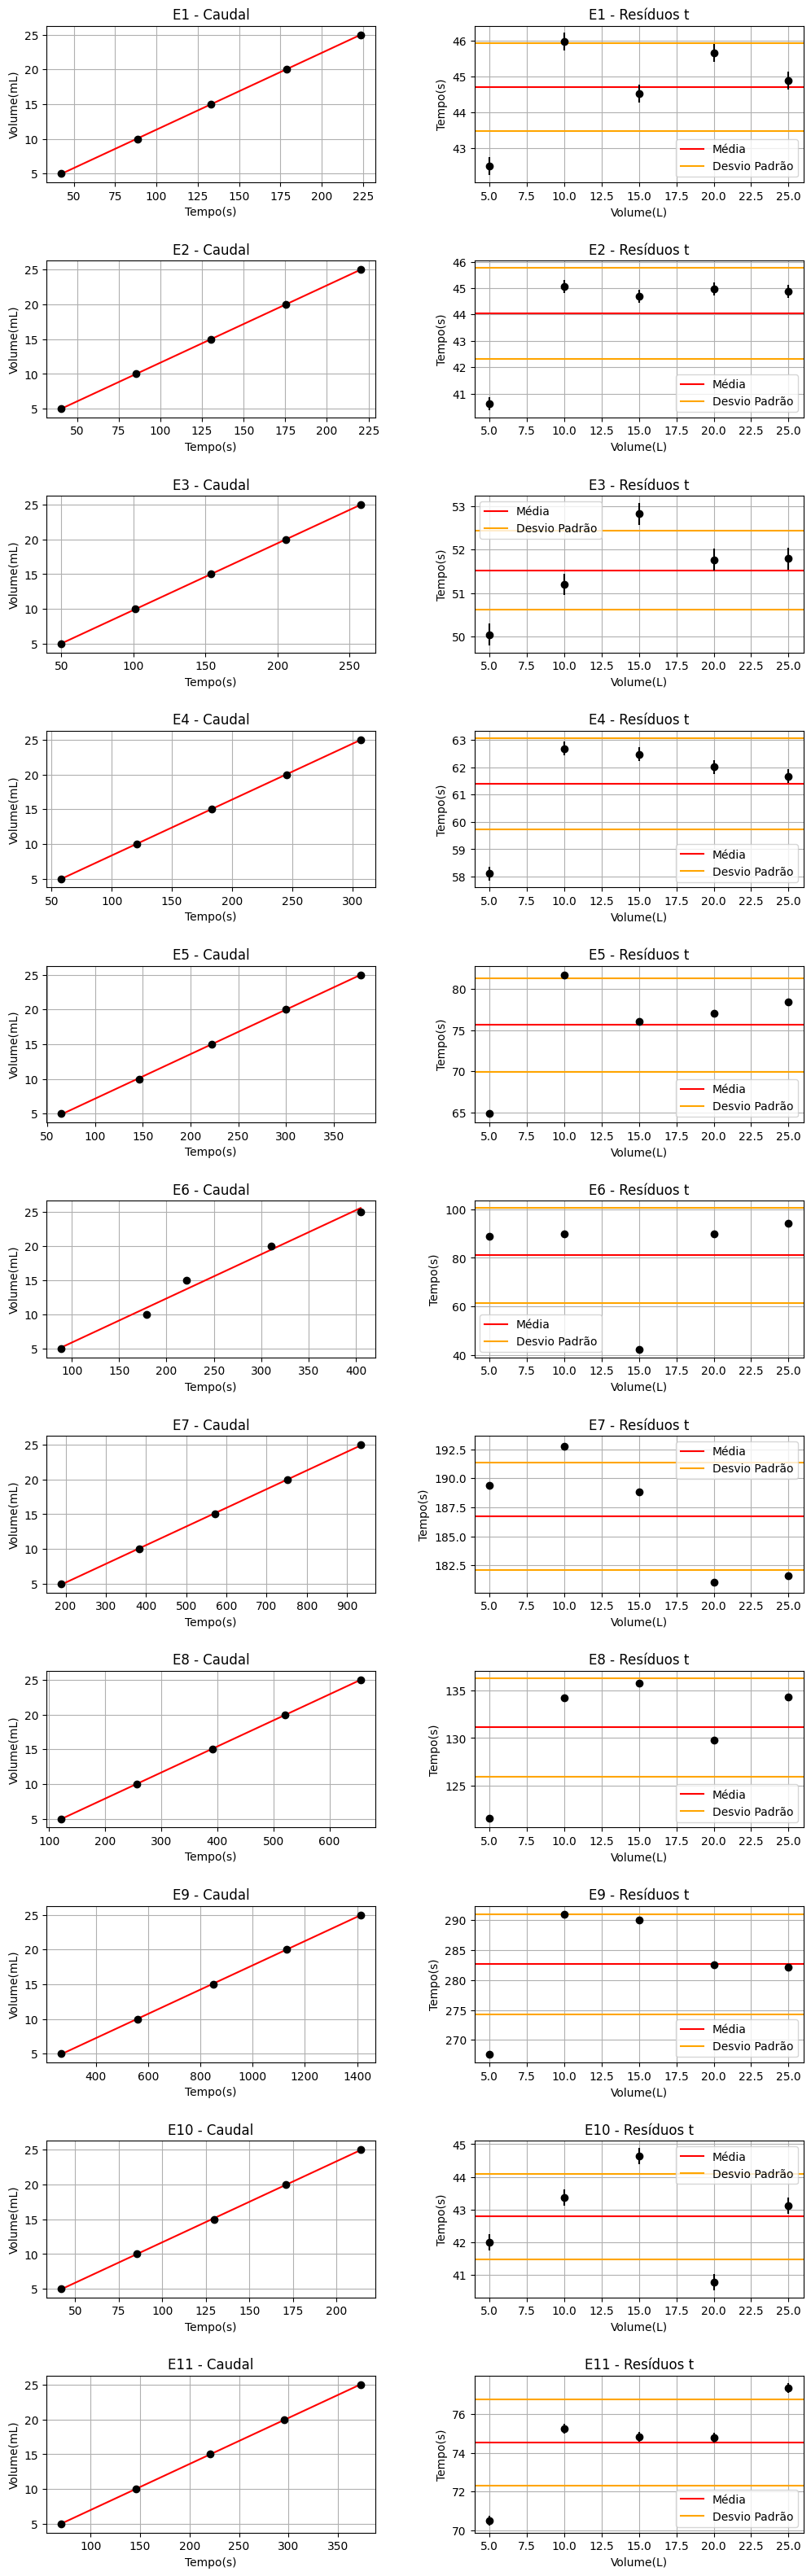

In [ ]:
t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,t11 = np.genfromtxt('tempos.txt', unpack=True, dtype=None, skip_header=0) 
ut = 0.01
uV= 0.25
dV = [5] * 5
V = [(i+1)*5 for i in range(5)]

ts = [t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,t11]
ensaio = 1

Qs = []
QsErr = []

fig, axs = plt.subplots(11,2,figsize=(12,40))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

for t0 in ts:
    #print(f"ENSAIO {ensaio}")

    media = np.average(t0)
    stdev = np.std(t0)

#gráfico 2
    axs[ensaio-1,1].axhline(y=0, color="red", label="Média")
    axs[ensaio-1,1].axhline(y=media+stdev, color="orange", label="Desvio Padrão")
    axs[ensaio-1,1].axhline(y=media-stdev, color="orange")

    axs[ensaio-1,1].errorbar(V, t0,yerr=uV,xerr=ut, fmt='o',color='k')
    axs[ensaio-1,1].set_title(f"E{ensaio} - Resíduos t")
    axs[ensaio-1,1].set_xlabel('Volume(L)')
    axs[ensaio-1,1].set_ylabel('Tempo(s)')
    axs[ensaio-1,1].legend()
    axs[ensaio-1,1].grid()
   

#gráfico 1

    t = t0
    for i in range(1,len(t0)):
        t[i] += t0[i-1]


    data1=RealData(t,V,ut,uV)
    odr=ODR(data1,linmod, beta0=[1,1])
    output=odr.run()
    #output.pprint()


    Qs.append(output.beta[0])
    QsErr.append(output.sd_beta[0])


    x=np.linspace(min(t), max(t))
    y=lin(output.beta, x)
    
    axs[ensaio-1,0].errorbar(t, V,yerr=uV,xerr=ut, fmt='o',color='k')
    axs[ensaio-1,0].plot(x,y,'r-')
    axs[ensaio-1,0].set_title(f"E{ensaio} - Caudal")
    axs[ensaio-1,0].set_xlabel('Tempo(s)')
    axs[ensaio-1,0].set_ylabel('Volume(mL)')
    axs[ensaio-1,0].grid()




    ensaio+=1
plt.show()


Beta: [328169.29875579    762.20235121]
Beta Std Error: [6871.83560715  532.75706356]
Beta Covariance: [[3870873.50295809 -268458.35651133]
 [-268458.35651133   23266.008868  ]]
Residual Variance: 12.199345851955675
Inverse Condition #: 0.03341776924978614
Reason(s) for Halting:
  Sum of squares convergence


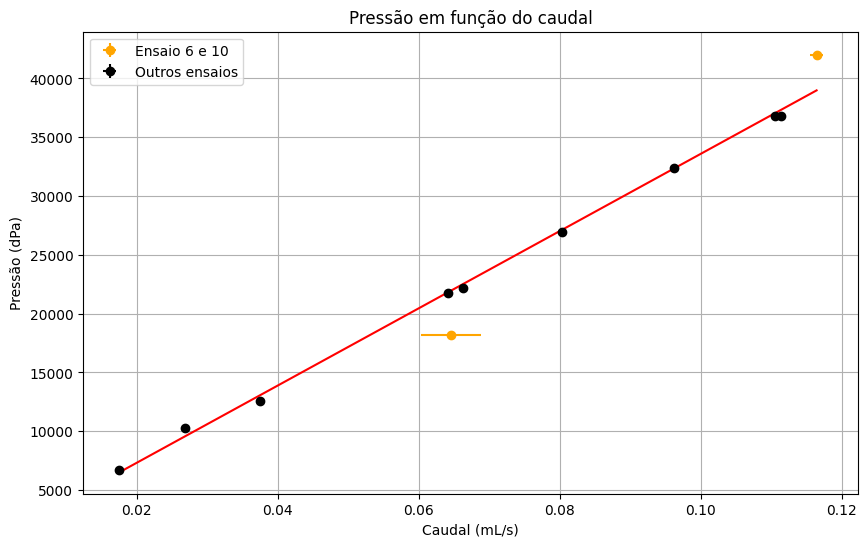

<Figure size 1000x600 with 0 Axes>

Ensaio 1
Caudal:  0.1105756421591981
Incerteza:  0.00028720177780282204


Ensaio 2
Caudal:  0.11138326515148844
Incerteza:  6.577245160439038e-05


Ensaio 3
Caudal:  0.09619846871361176
Incerteza:  0.00022844871779600551


Ensaio 4
Caudal:  0.08036684248258708
Incerteza:  0.0001569671934275572


Ensaio 5
Caudal:  0.06413650394023436
Incerteza:  0.00041360210103877045


Ensaio 6
Caudal:  0.06458011866458382
Incerteza:  0.004304223662804601


Ensaio 7
Caudal:  0.026900733601032043
Incerteza:  0.00022073980838675528


Ensaio 8
Caudal:  0.03749532888556275
Incerteza:  0.00014454861749442336


Ensaio 9
Caudal:  0.01745489267881708
Incerteza:  7.677949020053918e-05


Ensaio 10
Caudal:  0.1164614339581729
Incerteza:  0.0008993805405135947


Ensaio 11
Caudal:  0.06630077568180368
Incerteza:  0.00023733504170844237




In [ ]:
hs = np.genfromtxt('alturas.txt', unpack=True, dtype=None, skip_header=0)
ps = rho*g*hs

incp = 0.2*rho*g

data1=RealData(Qs,ps,QsErr,incp)
odr=ODR(data1,linmod, beta0=[1,1])
output=odr.run()
output.pprint()

err = 5
err2=9
plt.figure(figsize=(10,6))
plt.title("Pressão em função do caudal")
plt.xlabel("Caudal (mL/s)")
plt.ylabel("Pressão (dPa)")
plt.errorbar(Qs[0:err],ps[0:err],xerr=QsErr[0:err], yerr=incp, color="black", fmt="o")
plt.errorbar(Qs[err:err+1],ps[err:err+1],xerr=QsErr[err:err+1], yerr=incp, color="orange", fmt="o", label="Ensaio 6 e 10")
plt.errorbar(Qs[err+1:err2],ps[err+1:err2],xerr=QsErr[err+1:err2], yerr=incp, color="black", fmt="o", label="Outros ensaios")
plt.errorbar(Qs[err2:err2+1],ps[err2:err2+1],xerr=QsErr[err2:err2+1], yerr=incp, color="orange", fmt="o")
plt.errorbar(Qs[err2+1:],ps[err2+1:],xerr=QsErr[err2+1:], yerr=incp, color="black", fmt="o")
plt.legend()


x = np.linspace(min(Qs), max(Qs))
y = lin(output.beta, x)
plt.plot(x,y, color="red")
plt.grid()
plt.figure(figsize=(10,6))
plt.show()

for q in range(0, len(Qs)):
    print("Ensaio",q+1)
    print("Caudal: ", Qs[q])
    print("Incerteza: ", QsErr[q])
    print('\n')

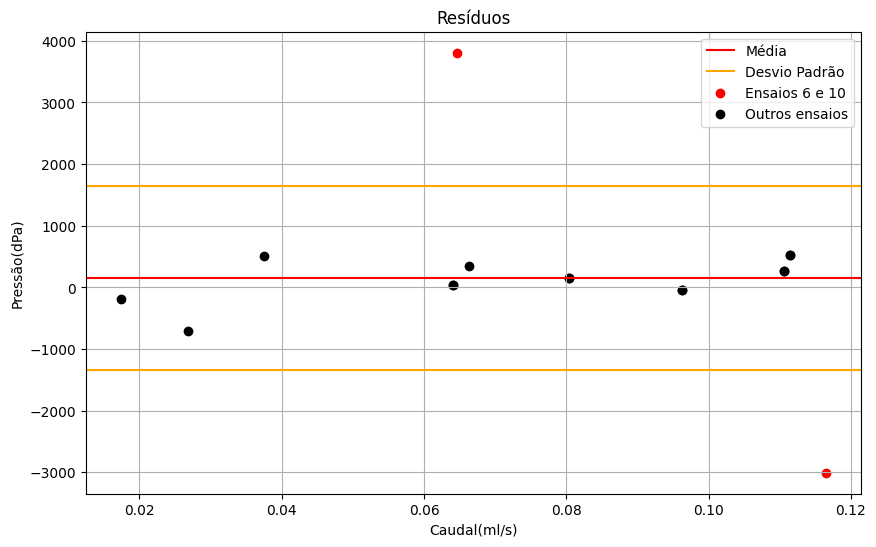

In [ ]:
y=[]
for i in range(11):
    s=lin(output.beta, Qs[i])-ps[i]
    y.append(s)

media = np.average(y)
std = np.std(y)

plt.figure(figsize=(10,6))
plt.axhline(y=media, color="red", label="Média")
plt.axhline(y=media+std, color="orange", label="Desvio Padrão")
plt.axhline(y=media-std, color="orange")
plt.scatter(Qs[:err],y[:err], color="k")
plt.scatter(Qs[err:err+1],y[err:err+1], color="red", label="Ensaios 6 e 10")
plt.scatter(Qs[err+1:err2],y[err+1:err2], color="k", label="Outros ensaios")
plt.scatter(Qs[err2:err2+1],y[err2:err2+1], color="red")
plt.scatter(Qs[err2+1:],y[err2+1:], color="k")
plt.scatter(Qs[:err],y[:err], color="k")
plt.title('Resíduos')
plt.xlabel('Caudal(ml/s)')
plt.ylabel('Pressão(dPa)')
plt.legend()
plt.grid()
plt.show()

Beta: [322408.23069069   1043.79824826]
Beta Std Error: [3531.11669179  266.09111148]
Beta Covariance: [[4239076.25513066 -285676.88241029]
 [-285676.88241029   24071.75888289]]
Residual Variance: 2.9413920251921115
Inverse Condition #: 0.032555250160274614
Reason(s) for Halting:
  Sum of squares convergence


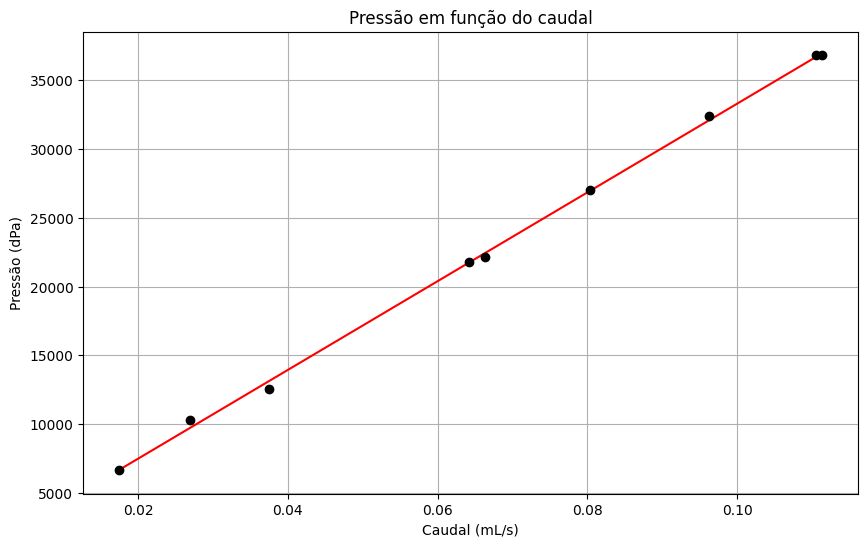

Beta: [ 3.10165780e-06 -3.23750534e-03]
Beta Std Error: [3.39703393e-08 8.57181827e-04]
Beta Covariance: [[ 3.92325791e-16 -8.93378163e-12]
 [-8.93378163e-12  2.49800325e-07]]
Residual Variance: 2.941392025192038
Inverse Condition #: 1.7073519843512896e-05
Reason(s) for Halting:
  Sum of squares convergence


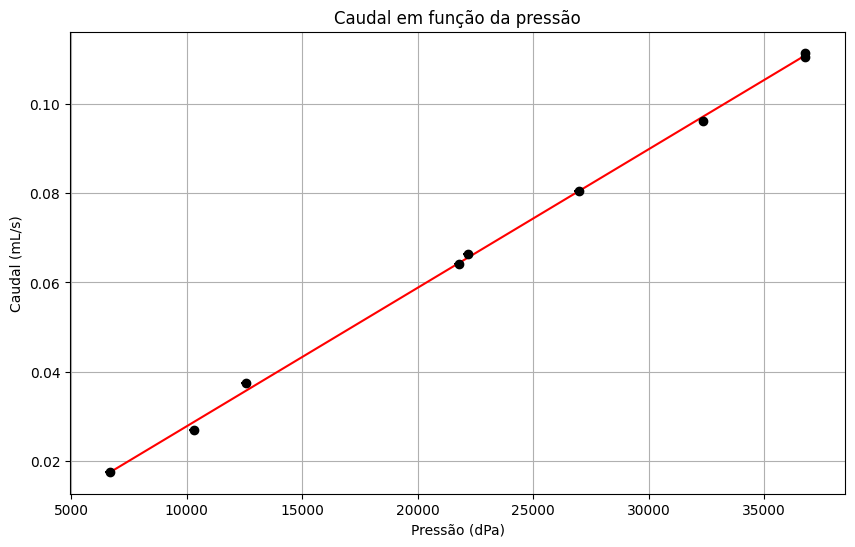

In [ ]:

Qs.pop(5)
Qs.pop(8)
QsErr.pop(5)
QsErr.pop(8)
ps = np.delete(ps, 5)
ps=np.delete(ps, 8)


data1=RealData(Qs,ps,QsErr,0.2*rho*g)
odr1=ODR(data1,linmod, beta0=[1,1])
output1=odr1.run()
output1.pprint()

plt.figure(figsize=(10,6))
plt.title("Pressão em função do caudal")
plt.xlabel("Caudal (mL/s)")
plt.ylabel("Pressão (dPa)")
plt.errorbar(Qs,ps,xerr=QsErr, yerr=incp, color="black", fmt="o")


x = np.linspace(min(Qs), max(Qs))
y = lin(output1.beta, x)
plt.plot(x,y, color="red")
plt.grid()
plt.show()


data2=RealData(ps,Qs,0.2*rho*g,QsErr)
odr2=ODR(data2,linmod, beta0=[1,1])
output2=odr2.run()
output2.pprint()


plt.figure(figsize=(10,6))
plt.title("Caudal em função da pressão")
plt.ylabel("Caudal (mL/s)")
plt.xlabel("Pressão (dPa)")
plt.errorbar(ps,Qs,yerr=QsErr, xerr=incp, color="black", fmt="o", label='Ensaios')
plt.legend()

x = np.linspace(min(ps), max(ps))
y = lin(output2.beta, x)
plt.plot(x,y, color="red")
plt.grid()
plt.show()

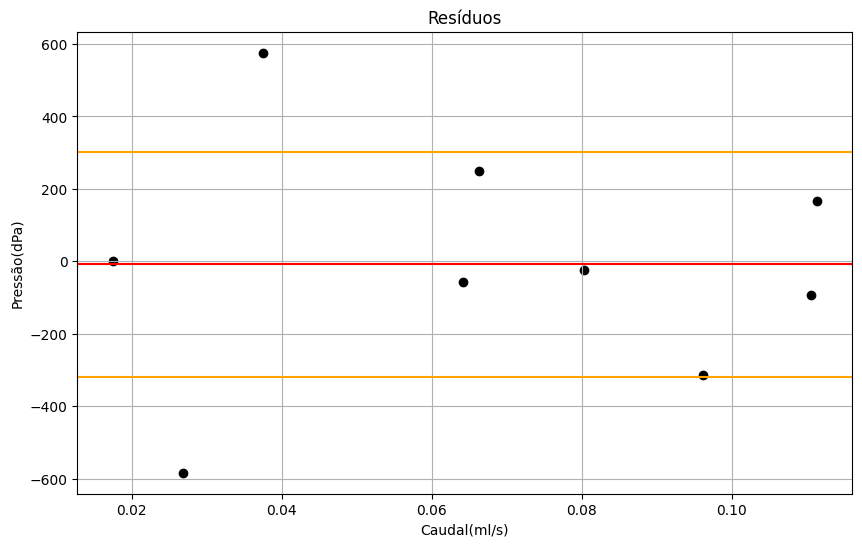

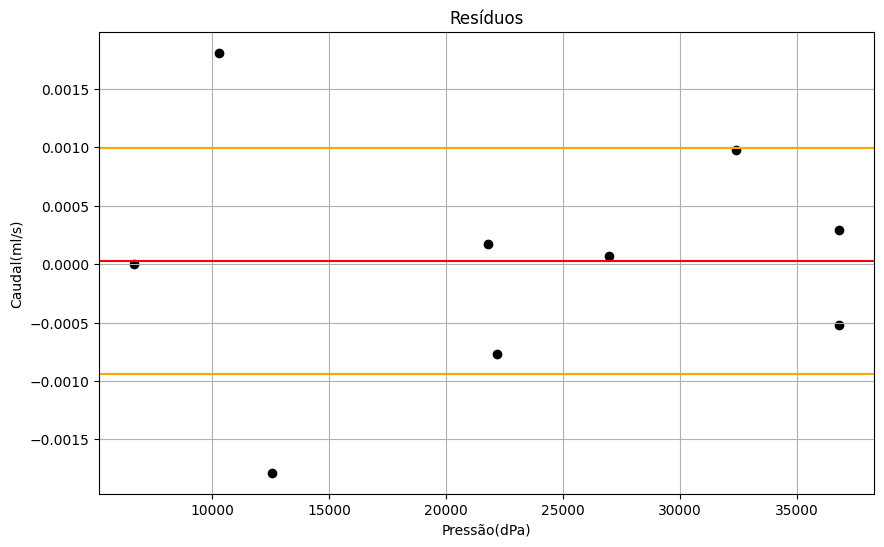

In [ ]:
y1=[]
for i in range(len(Qs)):
    s=lin(output1.beta, Qs[i])-ps[i]
    y1.append(s)

media1 = np.average(y1)
std1 = np.std(y1)

plt.figure(figsize=(10,6))
plt.axhline(y=media1, color="red", label="Média")
plt.axhline(y=media1+std1, color="orange", label="Desvio Padrão")
plt.axhline(y=media1-std1, color="orange")
plt.scatter(Qs,y1, color="k")
plt.title('Resíduos')
plt.xlabel('Caudal(ml/s)')
plt.ylabel('Pressão(dPa)')
plt.grid()
plt.show()


y2=[]
for i in range(len(ps)):
    s=lin(output2.beta, ps[i])-Qs[i]
    y2.append(s)

media2 = np.average(y2)
std2 = np.std(y2)


plt.figure(figsize=(10,6))
plt.axhline(y=media2, color="red", label="Média")
plt.axhline(y=media2+std2, color="orange", label="Desvio Padrão")
plt.axhline(y=media2-std2, color="orange")
plt.scatter(ps,y2, color="k")
plt.title('Resíduos')
plt.ylabel('Caudal(ml/s)')
plt.xlabel('Pressão(dPa)')
plt.grid()
plt.show()

In [ ]:
R = (792E-4)/2
l = 27.5

fator = 8*l/(np.pi*R**4)

eta = output1.beta[0]/fator

ul = 0.1
ur = (5E-4)/2

ueta = np.sqrt((np.pi*R**4/(8*l)*output1.sd_beta[0])**2 + (output1.beta[0]*R**4/(8*l**2)*ul)**2 + (4*output1.beta[0]*R**3/(8*l**2)*ur)**2)

print(f"η = {eta:.4f} ± {ueta:.4f} dPas")

etaSI = eta /1000*100
uetaSI = ueta/1000*100

etaReal15 = .001375
etaReal16 = .0011081

print(f"η (SI) = {etaSI:.5f} ± {uetaSI:.5f} Pas")
print(f"ε_r = {uetaSI/etaSI*100:.1f}%")

print(f"desvio relativo ao valor real 15 = {abs(etaSI-etaReal15)/etaReal15*100:.1f}%")
print(f"desvio relativo ao valor real 16 = {abs(etaSI-etaReal16)/etaReal16*100:.1f}%")

η = 0.0113 ± 0.0001 dPas
η (SI) = 0.00113 ± 0.00001 Pas
ε_r = 1.1%
desvio relativo ao valor real 15 = 17.7%
desvio relativo ao valor real 16 = 2.2%


In [ ]:
dh = output1.beta[1]/rho/g

print(f"Sistematicamente, a medida h (=|h1-h2|) tem um defeito de cerca de {dh:.1f} cm")

Sistematicamente, a medida h (=|h1-h2|) tem um defeito de cerca de 1.1 cm


In [ ]:
R = (792E-4)/2
l = 27.5

ul = 0.1
ur = (5E-4)/2

fator = (np.pi*R**4)/(8*l)

eta = fator/output2.beta[0]

ueta = np.sqrt((np.pi*R**4/(8*l*output2.beta[0]**2)*output2.sd_beta[0])**2 + (R**4/(8*l**2*output2.beta[0])*ul)**2 + (4*R**3/(8*l**2*output2.beta[0])*ur)**2)

print(f"η = {eta:.4f} ± {ueta:.4f} dPas")

etaSI = eta /1000*100
uetaSI = ueta/1000*100

print(f"η (SI) = {etaSI:.5f} ± {uetaSI:.5f} Pas")
print(f"ε_r = {uetaSI/etaSI*100:.1f}%")

print(f"desvio relativo ao valor real 15 = {abs(etaSI-etaReal15)/etaReal15*100:.1f}%")
print(f"desvio relativo ao valor real 16 = {abs(etaSI-etaReal16)/etaReal16*100:.1f}%")

η = 0.0113 ± 0.0001 dPas
η (SI) = 0.00113 ± 0.00001 Pas
ε_r = 1.1%
desvio relativo ao valor real 15 = 17.7%
desvio relativo ao valor real 16 = 2.2%
